In [1]:
# Realize a EDA (Exploratory Data Analysis) on the dataset of candidates 
import pandas as pd
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define the path to the dataset
path = r'/Users/valemoravale/Desktop/EDA/gbif_raw.csv'

# Load the dataset
df = pd.read_csv(path, sep=',')

# Show the first few rows of the dataset
print('Showing first few rows of the dataset:')
print(tabulate(df.head(), headers='keys', tablefmt='psql'))

Showing first few rows of the dataset:
+----+---------------------------------+---------------------------------+---------------------------------------+---------------+----------+----------+----------+----------------+-------------+-----------+---------------------+-------------------+------------------+
|    | nombre_cientifico_original      | nombre_cientifico_normalizado   | nombre_cientifico_gbif                |     usage_key | reino    | filo     | clase    | orden          | familia     | genero    | estado_taxonomico   |   confianza_match | categoria_iucn   |
|----+---------------------------------+---------------------------------+---------------------------------------+---------------+----------+----------+----------+----------------+-------------+-----------+---------------------+-------------------+------------------|
|  0 | PORPHYRULA MARTINICA (LINNAEUS) | Porphyrula martinica            | Porphyrula martinica (Linnaeus, 1766) |   2.47441e+06 | Animalia | Chordata | Aves

In [2]:
# Explore type of data in each column
print('\nData types of each column:')
print(tabulate(df.dtypes.to_frame(), headers='keys', tablefmt='psql'))

# Know how many rows and columns the dataset has
print('\nNumber of rows and columns in the dataset:')
print(tabulate([df.shape], headers=['Rows', 'Columns'], tablefmt='psql'))


Data types of each column:
+-------------------------------+---------+
|                               | 0       |
|-------------------------------+---------|
| nombre_cientifico_original    | object  |
| nombre_cientifico_normalizado | object  |
| nombre_cientifico_gbif        | object  |
| usage_key                     | float64 |
| reino                         | object  |
| filo                          | object  |
| clase                         | object  |
| orden                         | object  |
| familia                       | object  |
| genero                        | object  |
| estado_taxonomico             | object  |
| confianza_match               | int64   |
| categoria_iucn                | object  |
+-------------------------------+---------+

Number of rows and columns in the dataset:
+--------+-----------+
|   Rows |   Columns |
|--------+-----------|
|    567 |        13 |
+--------+-----------+


In [3]:
# % Missing values 
# 1. Calculamos los valores y el porcentaje
resumen = df.isnull().sum().to_frame(name='Total Nulos')
resumen['Porcentaje (%)'] = (resumen['Total Nulos'] / len(df)) * 100

print('\nAnálisis de valores faltantes por columna:')
print(tabulate(resumen, headers='keys', tablefmt='psql', floatfmt=".2f"))


Análisis de valores faltantes por columna:
+-------------------------------+---------------+------------------+
|                               |   Total Nulos |   Porcentaje (%) |
|-------------------------------+---------------+------------------|
| nombre_cientifico_original    |          0.00 |             0.00 |
| nombre_cientifico_normalizado |          0.00 |             0.00 |
| nombre_cientifico_gbif        |         41.00 |             7.23 |
| usage_key                     |         41.00 |             7.23 |
| reino                         |         41.00 |             7.23 |
| filo                          |         43.00 |             7.58 |
| clase                         |         48.00 |             8.47 |
| orden                         |        148.00 |            26.10 |
| familia                       |         46.00 |             8.11 |
| genero                        |         46.00 |             8.11 |
| estado_taxonomico             |         41.00 |          

In [4]:
# Cardinality od categorical columns 
# Check cardinality of categorical columns
print("\nCardinality of categorical columns:")
    

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("Categorical columns found:")
print(list(categorical_cols))

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique(dropna=False))
    print("Top values:")
    print(df[col].value_counts(dropna=False).head())


Cardinality of categorical columns:
Categorical columns found:
['nombre_cientifico_original', 'nombre_cientifico_normalizado', 'nombre_cientifico_gbif', 'reino', 'filo', 'clase', 'orden', 'familia', 'genero', 'estado_taxonomico', 'categoria_iucn']

--- nombre_cientifico_original ---
Unique values: 567
Top values:
nombre_cientifico_original
PORPHYRULA MARTINICA (LINNAEUS)    1
CORAGYPS ATRATUS BECHSTEIN         1
NO IDENTIFICADA                    1
INDETERMINADA                      1
ERYTHROLAMPUS TYPHLUS              1
Name: count, dtype: int64

--- nombre_cientifico_normalizado ---
Unique values: 541
Top values:
nombre_cientifico_normalizado
Forpus conspicillatus     3
Pionus menstruus          3
Cerdocyon thous           2
Dasypus novemcinctus      2
Odocoileus virginianus    2
Name: count, dtype: int64

--- nombre_cientifico_gbif ---
Unique values: 441
Top values:
nombre_cientifico_gbif
NaN                                       41
Pionus menstruus (Linnaeus, 1766)          7
Chel

In [5]:
# Basic Statistics spotify_dataset 
print("Describe data:")
df.describe()

Describe data:


,usage_key,confianza_match
count,5.260000e+02,567.000000
mean,3.684668e+06,89.781305
std,2.161495e+06,25.412042
min,1.000000e+00,0.000000
25%,2.443012e+06,95.000000
50%,2.480824e+06,99.000000
75%,5.220122e+06,99.000000
max,1.116000e+07,99.000000


In [6]:
#numero de duplicadas

print('\nNumber of duplicate rows in the dataset:')
print(df.duplicated().sum())


Number of duplicate rows in the dataset:
0


In [13]:
df.copy()

categoria_iucn_df = df[["categoria_iucn"]].dropna().copy()

categoria_iucn_df["categoria_iucn_normalizado"] = (
    categoria_iucn_df["categoria_iucn"]
    .str.strip()
    .str.lower()
)

repetidos_forma = (
    categoria_iucn_df.groupby("categoria_iucn_normalizado")["categoria_iucn"]
    .agg(["nunique", lambda x: list(x.unique())])
    .reset_index()
)

repetidos_forma.columns = ["categoria_iucn_normalizado", "formas_distintas", "variantes"]
repetidos_forma = repetidos_forma[repetidos_forma["formas_distintas"] > 1]

display(repetidos_forma)

,categoria_iucn_normalizado,formas_distintas,variantes



reino con mas miembros
+----------+---------+
| reino    |   count |
|----------+---------|
| Animalia |     525 |
| Plantae  |       1 |
+----------+---------+


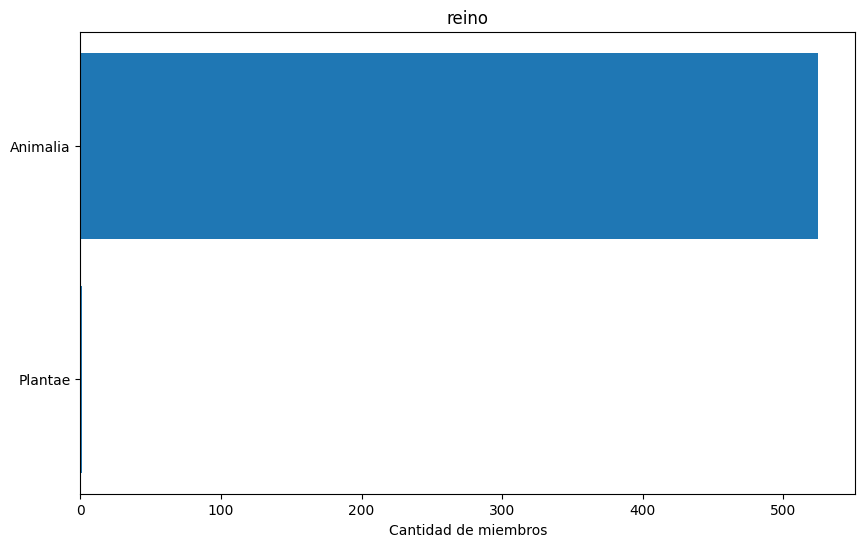

In [ ]:
# Conoce los reinos donde hay mas miembros
print('\nreino con mas miembros')
print(tabulate(df['reino'].value_counts().head(10).to_frame(), headers='keys', tablefmt='psql'))

# Bar plot horizontal 
import matplotlib.pyplot as plt

top_reino = df['reino'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_reino.index, top_reino.values)
plt.xlabel('Cantidad de miembros')
plt.title('reino')
plt.gca().invert_yaxis()
plt.show()


genero con mas miembros
+----------------+---------+
| genero         |   count |
|----------------+---------|
| Pionus         |      11 |
| Chelonoidis    |      10 |
| Ara            |       8 |
| Kinosternon    |       7 |
| Amazona        |       7 |
| Aratinga       |       6 |
| Leopardus      |       6 |
| Falco          |       6 |
| Erythrolamprus |       6 |
| Dasypus        |       6 |
+----------------+---------+


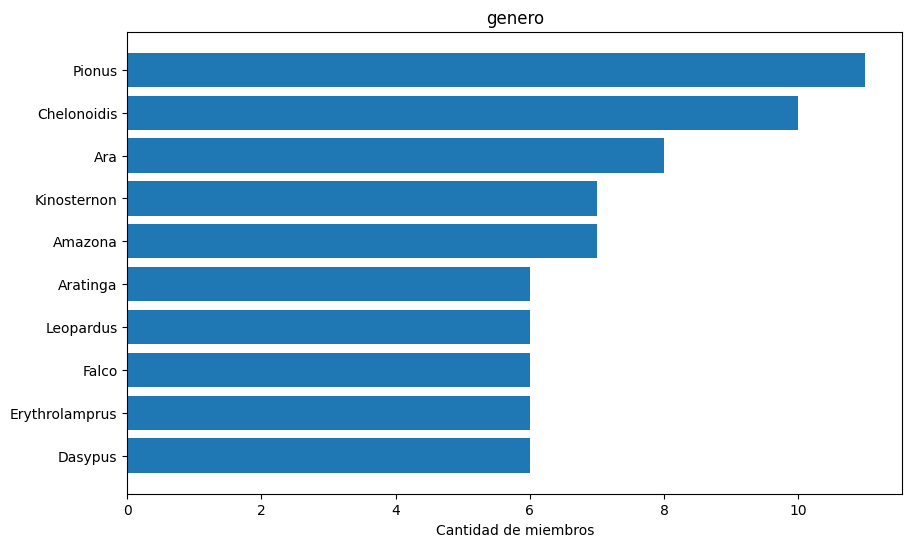

In [11]:
# Conocer genero donde hay mas miembros 
print('\ngenero con mas miembros')
print(tabulate(df['genero'].value_counts().head(10).to_frame(), headers='keys', tablefmt='psql'))

# Bar plot horizontal 
import matplotlib.pyplot as plt

top_genero = df['genero'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_genero.index, top_genero.values)
plt.xlabel('Cantidad de miembros')
plt.title('genero')
plt.gca().invert_yaxis()
plt.show()

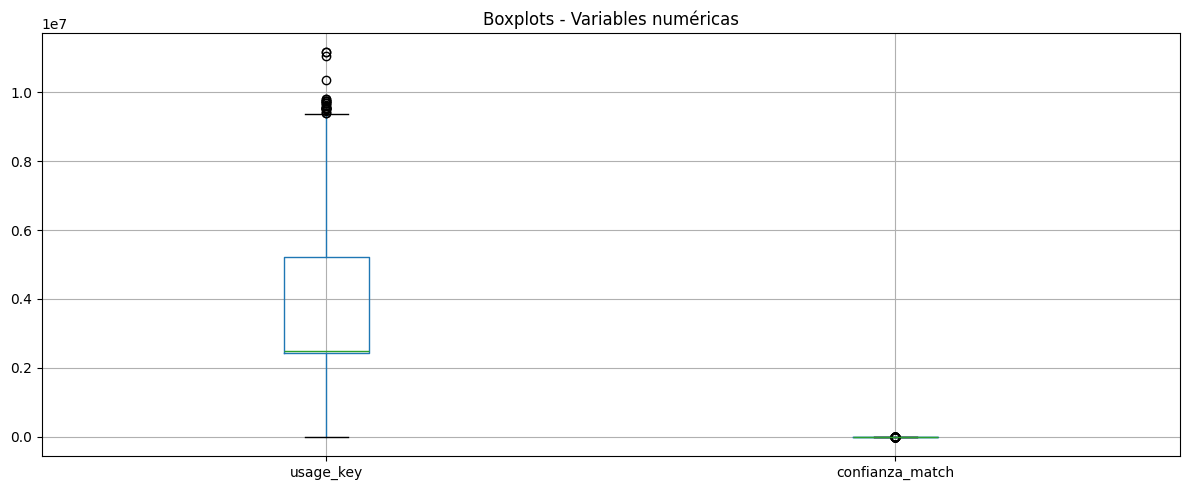

In [12]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols].boxplot(figsize=(12, 5), rot=0)
plt.title("Boxplots - Variables numéricas")
plt.tight_layout()
plt.show()